<a href="https://colab.research.google.com/github/vartiens/DeepLearningTrials/blob/main/aice3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning

## Feature selection

데이터의 변수들 중 모델 훈련에 가장 적합한 subset을 선택하는 과정

목표: **적은** 특징을 써서 **예측 능력**을 유지, **overfitting** 방지, 해석 가능성 향상

1. RFE(Recursive Feature Elimination)

모든 변수 써서 훈련 개시

-> 가장 덜 중요한 변수 제거

-> 목표 변수 개수에 도달할 때까지 반복

중요도: Decision tree의 변수 중요도, 선형 모델의 계수, 신경망의 가중치 계수 등을 기반으로 판정

최종적으로 선택된 변수들: 예측 정확도에 가장 큰 영향 주는 특성

2. RFE-CV(RFE with Cross Validation)

RFE에 cross validation을 추가

CV: 데이터를 분할해 검증 진행

변수 제거 시마다 CV를 진행하여 더 정확한 평가 가능

3. UFS(Univariate Feature Selection)

일변량 통계 기반으로 최적의 변수 선택

각 변수의 F-value 혹은 카이제곱 값을 통해 변수 평가

변수 평가가 편리하나 변수 간 관계 고려 불가 - 최상이 아닐수도 있다

## Machine Learning

scikit-learn 라이브러리 활용

1. 라이브러리 불러오기 - sklearn.XXX

2. 객체 생성 - 방법마다 쓰는 객체 다름

3. 학습 - .fit()

4. 예측 - .predict()

### 선형 회귀

데이터의 추세선을 이루는 1차 함수를 추정

sklearn.linear_model -> LinearRegression

.fit(data, target) 형태

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Test data generation
x = [] # 1행 데이터 -> reshape 필요
y = []
for i in range(0, 100):
  x.append(i)
  y.append(6 * i + 10)

# 선형 회귀 수행
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
x = np.array(x).reshape(-1, 1) # 1열 데이터로 reshape
y = np.array(y).reshape(-1, 1)
reg.fit(x, y) # fitting 진행 -> 기울기(coefficient), 절편(intercept) 생성

print(f'Coefficient: {reg.coef_}, Intercept: {reg.intercept_}')
xx = np.array([2434, 9991, -2938, -15342]).reshape(-1, 1)
reg.predict(xx)

Coefficient: [[6.]], Intercept: [10.]


array([[ 14614.],
       [ 59956.],
       [-17618.],
       [-92042.]])

In [3]:
# Case study - 건강검진 정보
import pandas as pd
dat = pd.read_csv('drive/MyDrive/dat/kor_health_2023.csv', encoding = 'cp949')
pd.set_option('display.max_columns', None)

# 데이터 전처리 - 쓸데없는 열 삭제
dat.drop(['구강검진수검여부', '치아우식증유무', '결손치 유무', '치아마모증유무', '제3대구치(사랑니) 이상', '치석'], axis = 1, inplace = True)
dat.drop(['기준년도', '가입자일련번호', '시도코드', '성별코드', '연령대코드(5세단위)'], axis = 1, inplace = True)

# 학습용 데이터 전처리
learn = dat.loc[dat['LDL콜레스테롤'].isnull() == False] # LDL 데이터가 있는 놈들 -> 학습에 사용
learn.dropna(inplace = True) # inplace 반드시!!!!!!
# learn.info()
target = learn['LDL콜레스테롤']
learn.drop(['LDL콜레스테롤'], axis = 1, inplace = True)

# 데이터 분할
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(learn, target, test_size = 0.33, random_state = 42)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

# 학습
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

# 학습 결과 - 각 feature의 가중치 확인
print('Coefficients:')
for i in range(len(x_train.columns)):
  print(f'{x_train.columns[i]}: {lr.coef_[i]}')
print(f'Intercept: {lr.intercept_}')

# 검증
y_pred = lr.predict(x_test)
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, y_pred) # RMSE 계산
print(f'RMSE: {rmse}')

# 콜레스테롤 관련 feature 삭제후 재시도
learn.drop(['총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤'], axis = 1, inplace = True)
x_train, x_test, y_train, y_test = train_test_split(learn, target, test_size = 0.33, random_state = 42)
lr2 = LinearRegression()
lr2.fit(x_train, y_train)
y_pred = lr2.predict(x_test)
rmse2 = root_mean_squared_error(y_test, y_pred)
print(f'RMSE after trimming: {rmse2}')

## 결과: coefficient가 큰 feature를 자르고 재실행 시 RMSE가 떡상 == 성능 떡락

# 테스트
test = dat.loc[dat['LDL콜레스테롤'].isnull()] # LDL 데이터가 없는 놈들 -> 추정
test.drop('LDL콜레스테롤', axis = 1, inplace = True)
test.dropna(inplace = True)
test_res = lr.predict(test)
print(test_res)

/tmp/ipykernel_699/793813923.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  learn.dropna(inplace = True) # inplace 반드시!!!!!!
/tmp/ipykernel_699/793813923.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  learn.drop(['LDL콜레스테롤'], axis = 1, inplace = True)


(221550, 21) (221550,) (109123, 21) (109123,)
Coefficients:
신장(5cm단위): 0.010195014046252443
체중(5kg단위): 0.0012924988711676966
허리둘레: 0.013105051930779148
시력(좌): -0.03481099759446013
시력(우): -0.0034425596412850446
청력(좌): 0.10130850546159563
청력(우): 0.17870514818669625
수축기혈압: -0.0027127880871261134
이완기혈압: -0.0008310691830174182
식전혈당(공복혈당): -0.002340682334255675
총콜레스테롤: 0.9944818806911626
트리글리세라이드: -0.1945730178489754
HDL콜레스테롤: -0.9607332391743036
혈색소: 0.04203496485009712
요단백: 0.055490508458685604
혈청크레아티닌: 0.048624938857306475
혈청지오티(AST): -0.0021521928204328066
혈청지피티(ALT): 0.0014722784556214265
감마지티피: -0.0009274709507389005
흡연상태: -0.025868342405030473
음주여부: -0.06281706211107875
Intercept: -4.894223620125572
RMSE: 3.934931960874841


/tmp/ipykernel_699/793813923.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  learn.drop(['총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤'], axis = 1, inplace = True)


RMSE after trimming: 37.20051701570436
[ 54.7372735  121.6086631  101.0828796  ...  51.79080045  40.07329806
  92.07423432]


/tmp/ipykernel_699/793813923.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.drop('LDL콜레스테롤', axis = 1, inplace = True)
/tmp/ipykernel_699/793813923.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.dropna(inplace = True)


로지스틱 회귀

Sigmoid 함수를 사용한 추정

이름은 '회귀'지만 사실 분류 모델에 사용

함수: S(x) = 1/(1+e^-X)

-> X = b_1x + b_0

(b_1: coefficient, b_0: intercept)

모델링을 하면 b_0과 b_1을 얻는다.

sklearn.linear_model -> LogisticRegression

    파라미터: max_iter, penalty, C

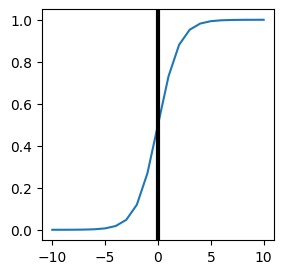

In [20]:
# sigmoid 함수 생성
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def sigsig(x, b1, b0):
  return 1 / (1 + np.exp(-(b1 * x + b0)))

x = range(-10, 11)
y = sigmoid(np.array(x))
plt.figure(figsize = (3, 3))
plt.plot(x, y)
plt.axvline(x = 0, color = 'black', linewidth = 3) # x축에 수직(vertical)으로 선 삽입
plt.show()

[[ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]
 [13]
 [14]
 [15]
 [16]
 [17]]
[[1.19388731]] & [-11.34176791]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


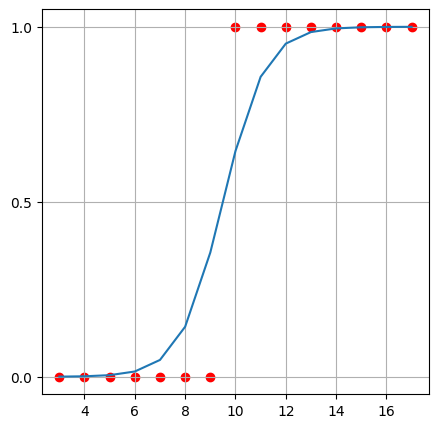

In [29]:
# 9 초과이면 1, 그렇지 않으면 0으로 분류
x_train = np.array(range(3, 18)).reshape(-1, 1)
y_train = np.array([0] * 7 + [1] * 8). reshape(-1, 1)
print(x_train)

x_test = np.array([0, 1, 2, 18, 19]).reshape(-1, 1)
y_test = np.array([0, 0, 0, 1, 1]).reshape(-1, 1)

from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(x_train, y_train)
print(f'{lor.coef_} & {lor.intercept_}')

y_sigmoid = sigsig(x_train, lor.coef_, lor.intercept_)
plt.figure(figsize = (5, 5))
plt.scatter(x_train, y_train, color = 'red')
plt.plot(x_train, y_sigmoid)
plt.rcParams['axes.grid'] = True # 그래프에 격자 삽입
plt.yticks([0, 0.5, 1])
plt.show()

선형 회귀 vs 로지스틱 회귀

데이터를 두 부류로 분류할 때는 로지스틱이 더 좋은 성능을 보인다.

[[0.1]] & [-0.46666667]


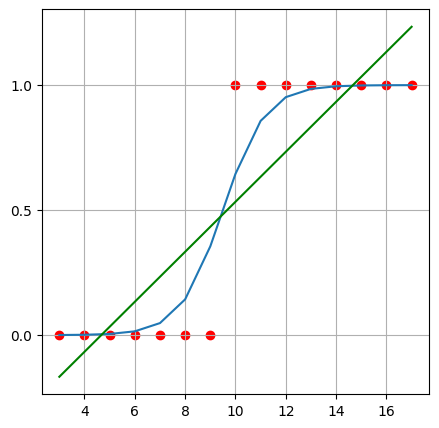

LoR: 1 vs LR: 0


In [42]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
print(f'{lr.coef_} & {lr.intercept_}')

y_linear = lr.coef_ * x_train + lr.intercept_
plt.figure(figsize = (5, 5))
plt.scatter(x_train, y_train, color = 'red')
plt.plot(x_train, y_sigmoid)
plt.plot(x_train, y_linear, color = 'green')
plt.rcParams['axes.grid'] = True # 그래프에 격자 삽입
plt.yticks([0, 0.5, 1])
plt.show()

# 9.5에 대해 어떤 추정값을 내놓는지 비교
nparr95 = np.array(9.5).reshape(-1, 1)
lor_95 = lor.predict(nparr95)
lr_95 = lr.predict(nparr95)
print(f'LoR: {lor_95[0]} vs LR: {round(lr_95[0][0])}') # 선형: 0.4(0), 로지스틱: 1